In [ ]:
import pandas as pd

In [ ]:

url = "https://raw.githubusercontent.com/GeethaGunasekaran1/Dataset_rep/refs/heads/main/social_media_engagement_5000.csv"
df = pd.read_csv(url)

df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [ ]:
print(df.info())
print(df.dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   str    
 3   country           5000 non-null   str    
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   str    
 6   post_category     5000 non-null   str    
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   str    
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   str    
 16  sentiment         4850 non-null   str    
 17  hashta

In [ ]:
import pandas as pd

df['posted_at'] = pd.to_datetime(df['posted_at'], format='%d-%m-%Y', errors='coerce')

print(df['posted_at'].dtype)
print(df[['posted_at']].head())

datetime64[us]
   posted_at
0 2022-12-17
1 2023-06-02
2 2023-05-07
3 2023-02-12
4 2023-05-23


In [ ]:
import numpy as np

likes_array = df['likes'].to_numpy()

print("Mean likes:", np.mean(likes_array))
print("Median likes:", np.median(likes_array))
print("Maximum likes:", np.max(likes_array))
print("Standard Deviation of likes:", np.std(likes_array))

Mean likes: nan
Median likes: nan
Maximum likes: nan
Standard Deviation of likes: nan


Data Cleaning

In [ ]:
df.isnull().sum()

user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64

In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

df.reset_index(drop=True, inplace=True)

Number of duplicate rows: 0


In [ ]:
numeric_cols = ['likes', 'comments', 'shares', 'impression_count', 'follower_count', 'watch_time_sec', 'engagement_rate']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
print(df['gender'].value_counts())

df['gender'] = df['gender'].str.strip().str.capitalize()

gender
Male      1699
Other     1581
Female    1570
Name: count, dtype: int64


In [ ]:
df['hashtags'] = df['hashtags'].fillna('')
df['hashtag_count'] = df['hashtags'].apply(lambda x: len(x.split()) if x.strip() != '' else 0)

print(df[['hashtags', 'hashtag_count']].head())

                hashtags  hashtag_count
0  #foodie #travel #love              3
1               #fitness              1
2                #foodie              1
3    #music #foodie #fun              3
4                #travel              1


In [ ]:
print(df['sentiment'].value_counts())

df['sentiment'] = df['sentiment'].astype(str).str.strip().str.lower()

sentiment
positive    2363
neutral     1527
negative     960
Name: count, dtype: int64


DATA EXPLORATION USING PANDAS

In [ ]:
print("--- HEAD ---")
display(df.head())

print("--- TAIL ---")
display(df.tail())

print("--- SHAPE ---")
print(df.shape)

print("--- COLUMNS ---")
print(df.columns)

--- HEAD ---


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1


--- TAIL ---


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,2023-03-04,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527,3


--- SHAPE ---
(5000, 20)
--- COLUMNS ---
Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count'],
      dtype='str')


In [ ]:
print("--- INFO ---")
df.info()

print("\n--- DTYPES ---")
print(df.dtypes)

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               4850 non-null   float64       
 2   gender            4850 non-null   str           
 3   country           5000 non-null   str           
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   str           
 6   post_category     5000 non-null   str           
 7   likes             4850 non-null   float64       
 8   comments          4850 non-null   float64       
 9   shares            4850 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[us]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000

In [ ]:
df.describe()

print("--- VALUE COUNTS ---")
print(df['post_type'].value_counts())

print("\n--- UNIQUE VALUES ---")
print(df['country'].unique())

print("\n--- NUMBER OF UNIQUE VALUES ---")
print(df['country'].nunique())

--- VALUE COUNTS ---
post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64

--- UNIQUE VALUES ---
<ArrowStringArray>
[   'Brazil',        'UK',    'France',    'Canada',     'Japan', 'Australia',
     'India',       'UAE',   'Germany',       'USA']
Length: 10, dtype: str

--- NUMBER OF UNIQUE VALUES ---
10


                   user_id       age   post_id     likes  comments    shares  \
user_id           1.000000 -0.006789  0.020051  0.026228 -0.033874  0.014004   
age              -0.006789  1.000000 -0.013353 -0.037371 -0.007491  0.014348   
post_id           0.020051 -0.013353  1.000000  0.014773 -0.010724  0.001901   
likes             0.026228 -0.037371  0.014773  1.000000 -0.018980  0.004799   
comments         -0.033874 -0.007491 -0.010724 -0.018980  1.000000  0.006310   
shares            0.014004  0.014348  0.001901  0.004799  0.006310  1.000000   
watch_time_sec   -0.016847  0.005677  0.018374  0.008837 -0.016616  0.014898   
impression_count  0.015326  0.013513 -0.007709  0.008067 -0.009537 -0.005178   
follower_count    0.010124 -0.025416 -0.002844 -0.023331 -0.011921 -0.010891   
engagement_rate  -0.004282  0.008044  0.010139  0.093555  0.000046  0.021804   
hashtag_count    -0.013692  0.007336  0.007344 -0.002224 -0.015450  0.013642   

                  watch_time_sec  impre

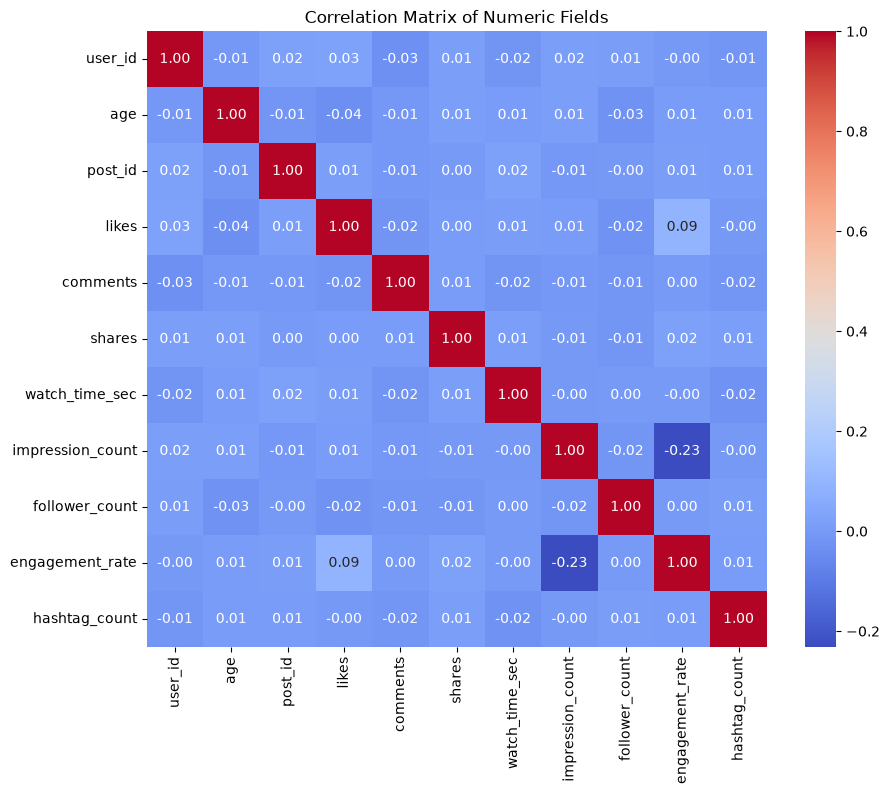

In [ ]:
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()

print(correlation_matrix)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numeric Fields")
plt.show()

In [ ]:
print("--- Average Likes by Post Type ---")
print(df.groupby('post_type')['likes'].mean())

print("\n--- Average Impressions by Country ---")
print(df.groupby('country')['impression_count'].mean())

print("\n--- Summary by Post Type and Sentiment ---")
print(df.groupby(['post_type', 'sentiment'])[['likes', 'comments']].mean())

--- Average Likes by Post Type ---
post_type
image    10104.848560
reel     10035.341680
text     10099.975124
video    10190.972292
Name: likes, dtype: float64

--- Average Impressions by Country ---
country
Australia    48346.383367
Brazil       49193.174603
Canada       48703.150097
France       51727.673387
Germany      48605.406122
India        52462.386916
Japan        49616.135593
UAE          48928.413519
UK           51119.393509
USA          51263.872255
Name: impression_count, dtype: float64

--- Summary by Post Type and Sentiment ---
                            likes     comments
post_type sentiment                           
image     negative    9913.236967  1480.244131
          neutral     9863.906915  1546.448819
          positive   10296.032702  1535.607018
reel      negative   10645.677419  1533.008065
          neutral     9882.748663  1598.288360
          positive    9879.170648  1437.532534
text      negative    9979.577093  1526.298246
          neutral     992

DATA WRANGLING

In [ ]:
df['engagement_score'] = (df['likes'] * 1) + (df['comments'] * 2) + (df['shares'] * 3)

import numpy as np
df['log_likes'] = np.log1p(df['likes'])

print(df[['likes', 'comments', 'shares', 'engagement_score', 'log_likes']].head())

     likes  comments  shares  engagement_score  log_likes
0   7011.0     354.0  1157.0           11190.0   8.855378
1  11750.0    2606.0  1807.0           22383.0   9.371694
2   4862.0     344.0   955.0            8415.0   8.489411
3   5350.0    1083.0  1049.0           10663.0   8.585039
4  12682.0    2735.0  1300.0           22052.0   9.448018


In [ ]:
print("--- Average Engagement Score by Post Type and Country ---")
print(df.groupby(['post_type', 'country'])['engagement_score'].mean().unstack())

print("\n--- Summary Metrics by Sentiment and Post Type ---")
print(df.groupby(['sentiment', 'post_type'])[['likes', 'comments', 'shares']].mean())

--- Average Engagement Score by Post Type and Country ---
country       Australia        Brazil        Canada        France  \
post_type                                                           
image      16095.429752  15374.969697  15691.577778  17179.601695   
reel       16257.266667  15951.868421  16624.591667  16225.153153   
text       16645.358974  16158.640351  16101.294737  15799.883929   
video      16799.247788  16171.117117  16398.213115  16383.974138   

country         Germany         India         Japan           UAE  \
post_type                                                           
image      16907.800000  16246.008333  15740.612903  16792.536364   
reel       15623.784314  15553.615385  16116.580357  16200.030075   
text       16151.891667  16464.959016  16406.313043  15692.028846   
video      15899.920354  16271.019608  16160.672566  16010.211009   

country              UK           USA  
post_type                              
image      15791.540541  16159.5

STATISTICAL ANALYSIS

In [ ]:
metrics = ['likes', 'comments', 'shares', 'watch_time_sec', 'engagement_rate', 'follower_count']

print("--- MEAN ---")
print(df[metrics].mean())

print("\n--- MEDIAN ---")
print(df[metrics].median())

--- MEAN ---
likes               10107.043711
comments             1502.195670
shares               1002.629485
watch_time_sec       4014.503200
engagement_rate         0.964356
follower_count     393698.224800
dtype: float64

--- MEDIAN ---
likes               10105.500000
comments             1497.000000
shares               1012.000000
watch_time_sec       4034.500000
engagement_rate         0.253896
follower_count     388982.000000
dtype: float64


In [ ]:
print("--- STANDARD DEVIATION ---")
print(df[metrics].std())

print("\n--- VARIANCE ---")
print(df[metrics].var())

--- STANDARD DEVIATION ---
likes                5789.819252
comments              869.537889
shares                579.615158
watch_time_sec       2308.096459
engagement_rate         5.318029
follower_count     230927.884535
dtype: float64

--- VARIANCE ---
likes              3.352201e+07
comments           7.560961e+05
shares             3.359537e+05
watch_time_sec     5.327309e+06
engagement_rate    2.828143e+01
follower_count     5.332769e+10
dtype: float64


In [ ]:
print(df[metrics].quantile([0.25, 0.50, 0.75]))

        likes  comments  shares  watch_time_sec  engagement_rate  \
0.25   5068.5     760.0   498.0         2017.75         0.145781   
0.50  10105.5    1497.0  1012.0         4034.50         0.253896   
0.75  15115.0    2256.0  1501.0         6020.25         0.504794   

      follower_count  
0.25       194480.00  
0.50       388982.00  
0.75       589744.25  


In [ ]:
print("--- SKEWNESS ---")
print(df[metrics].skew())

print("\n--- KURTOSIS ---")
print(df[metrics].kurtosis())

--- SKEWNESS ---
likes              -0.006813
comments            0.003206
shares             -0.012977
watch_time_sec     -0.018196
engagement_rate    18.781271
follower_count      0.041118
dtype: float64

--- KURTOSIS ---
likes               -1.205547
comments            -1.200096
shares              -1.202503
watch_time_sec      -1.195652
engagement_rate    482.991739
follower_count      -1.189474
dtype: float64


DATA VISUALISATION

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid")

Matplotlib

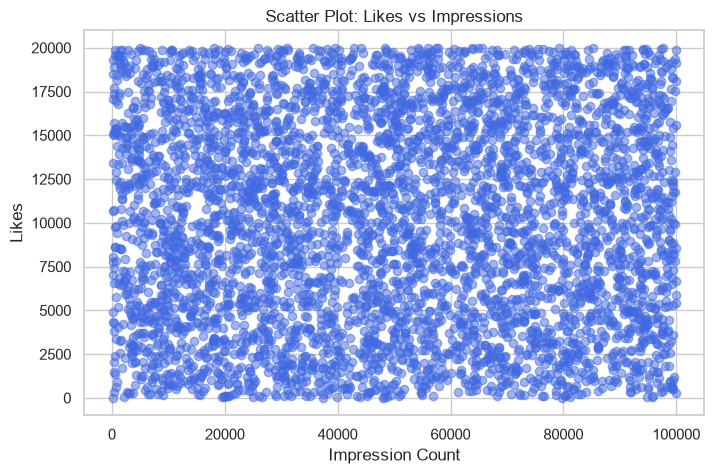

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['impression_count'], df['likes'], alpha=0.5, color='royalblue')
plt.title('Scatter Plot: Likes vs Impressions')
plt.xlabel('Impression Count')
plt.ylabel('Likes')
plt.show()

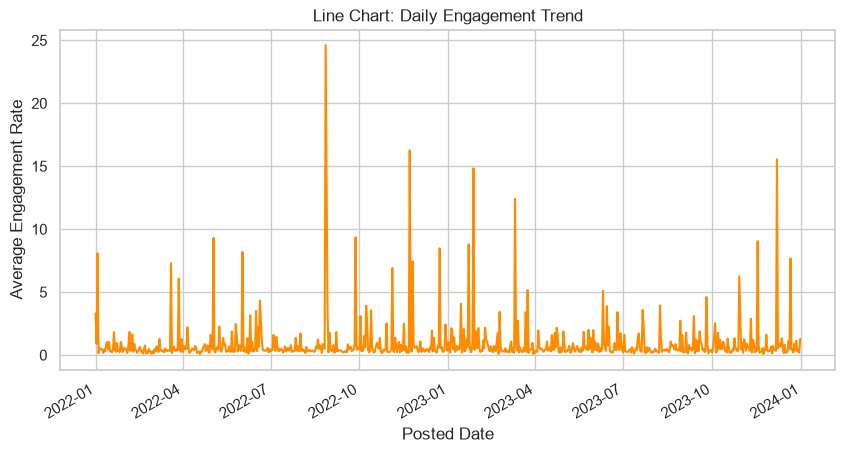

In [ ]:
plt.figure(figsize=(10, 5))
daily_trend = df.groupby('posted_at')['engagement_rate'].mean()
daily_trend.plot(kind='line', color='darkorange')
plt.title('Line Chart: Daily Engagement Trend')
plt.xlabel('Posted Date')
plt.ylabel('Average Engagement Rate')
plt.show()

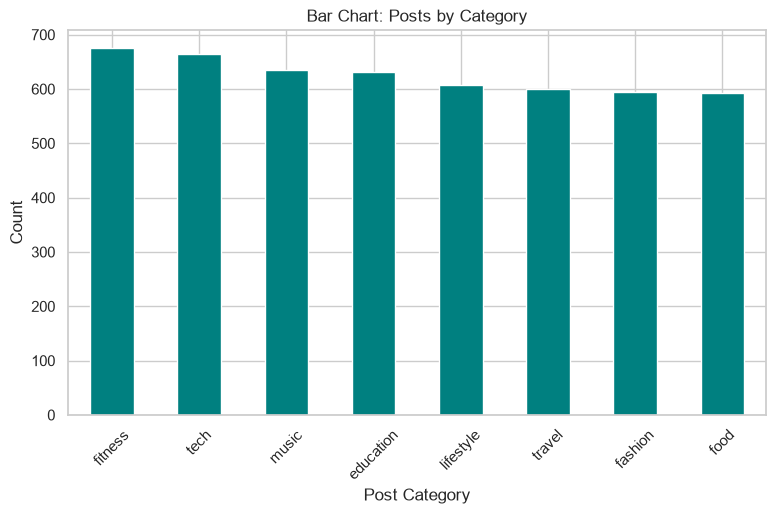

In [ ]:
plt.figure(figsize=(9, 5))
df['post_category'].value_counts().plot(kind='bar', color='teal')
plt.title('Bar Chart: Posts by Category')
plt.xlabel('Post Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

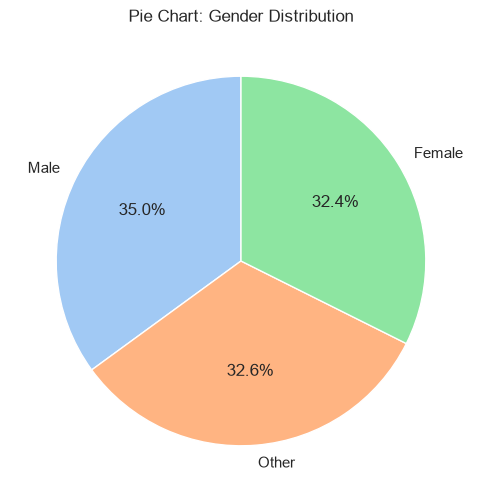

In [ ]:
plt.figure(figsize=(6, 6))
df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Pie Chart: Gender Distribution')
plt.ylabel('')
plt.show()


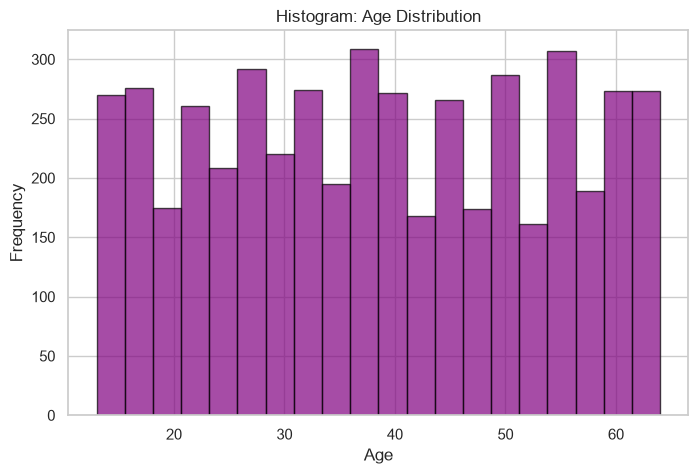

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df['age'].dropna(), bins=20, color='purple', edgecolor='black', alpha=0.7)
plt.title('Histogram: Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


C:\Users\hp\AppData\Local\Temp\ipykernel_7548\2306068642.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df['engagement_rate'].dropna(), vert=False, patch_artist=True, boxprops=dict(facecolor='skyblue'))


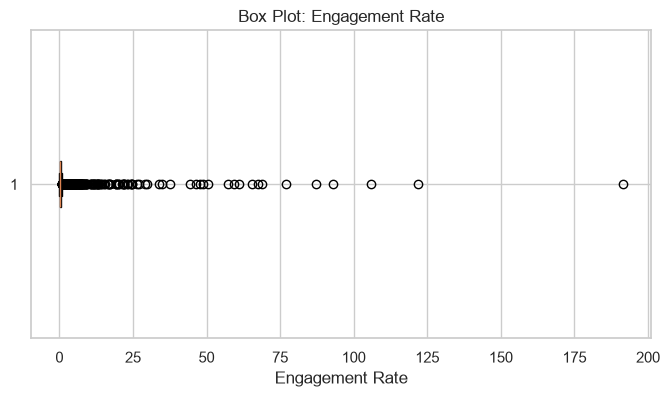

In [ ]:
plt.figure(figsize=(8, 4))
plt.boxplot(df['engagement_rate'].dropna(), vert=False, patch_artist=True, boxprops=dict(facecolor='skyblue'))
plt.title('Box Plot: Engagement Rate')
plt.xlabel('Engagement Rate')
plt.show()

Seaborn

C:\Users\hp\AppData\Local\Temp\ipykernel_7548\2685700093.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='post_type', palette='Set2')


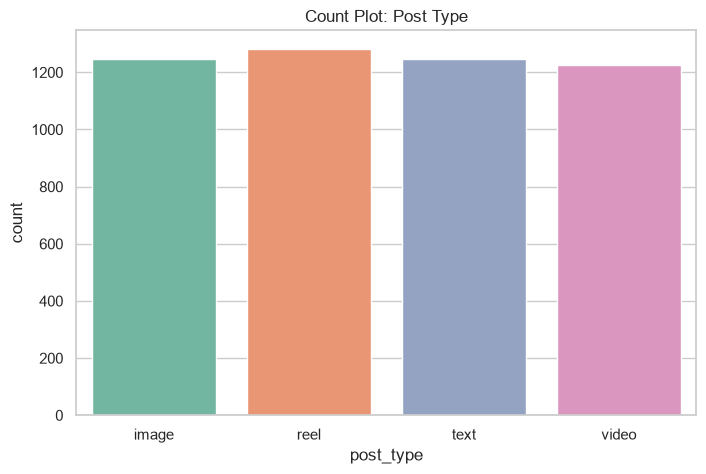

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='post_type', palette='Set2')
plt.title('Count Plot: Post Type')
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_7548\524026476.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='post_category', y='likes', estimator=lambda x: sum(x) / len(x), palette='viridis')


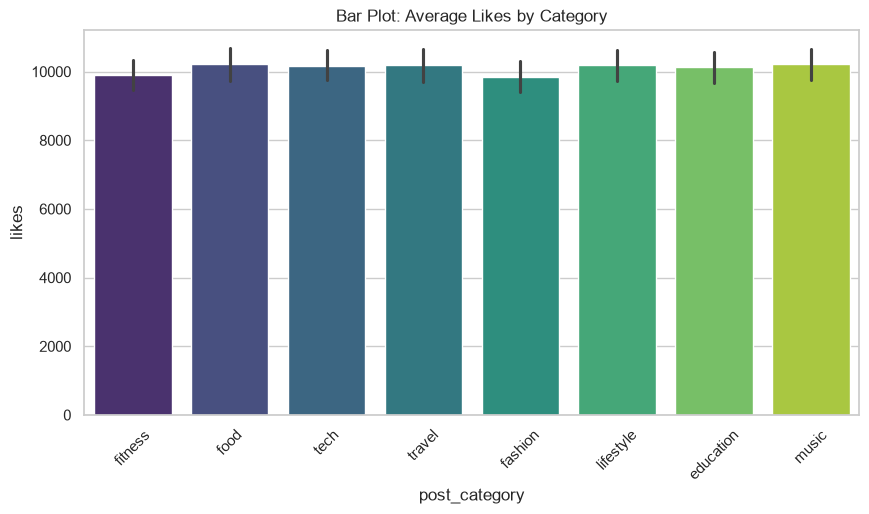

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='post_category', y='likes', estimator=lambda x: sum(x) / len(x), palette='viridis')
plt.title('Bar Plot: Average Likes by Category')
plt.xticks(rotation=45)
plt.show()


C:\Users\hp\AppData\Local\Temp\ipykernel_7548\3916480112.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='sentiment', y='follower_count', palette='muted')


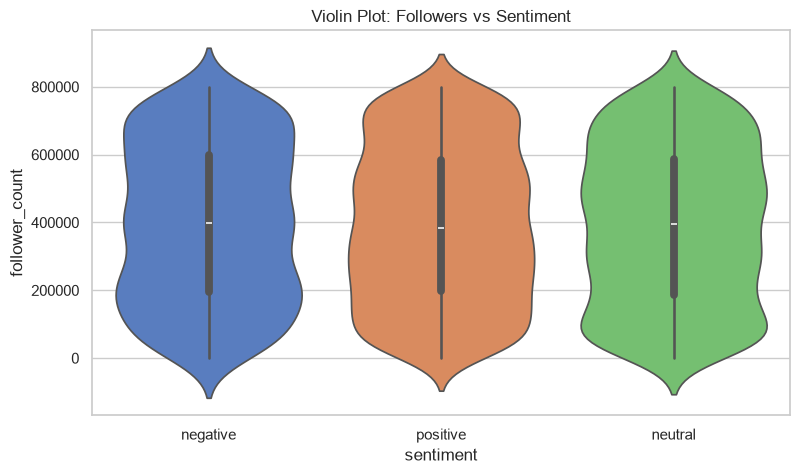

In [ ]:
plt.figure(figsize=(9, 5))
sns.violinplot(data=df, x='sentiment', y='follower_count', palette='muted')
plt.title('Violin Plot: Followers vs Sentiment')
plt.show()

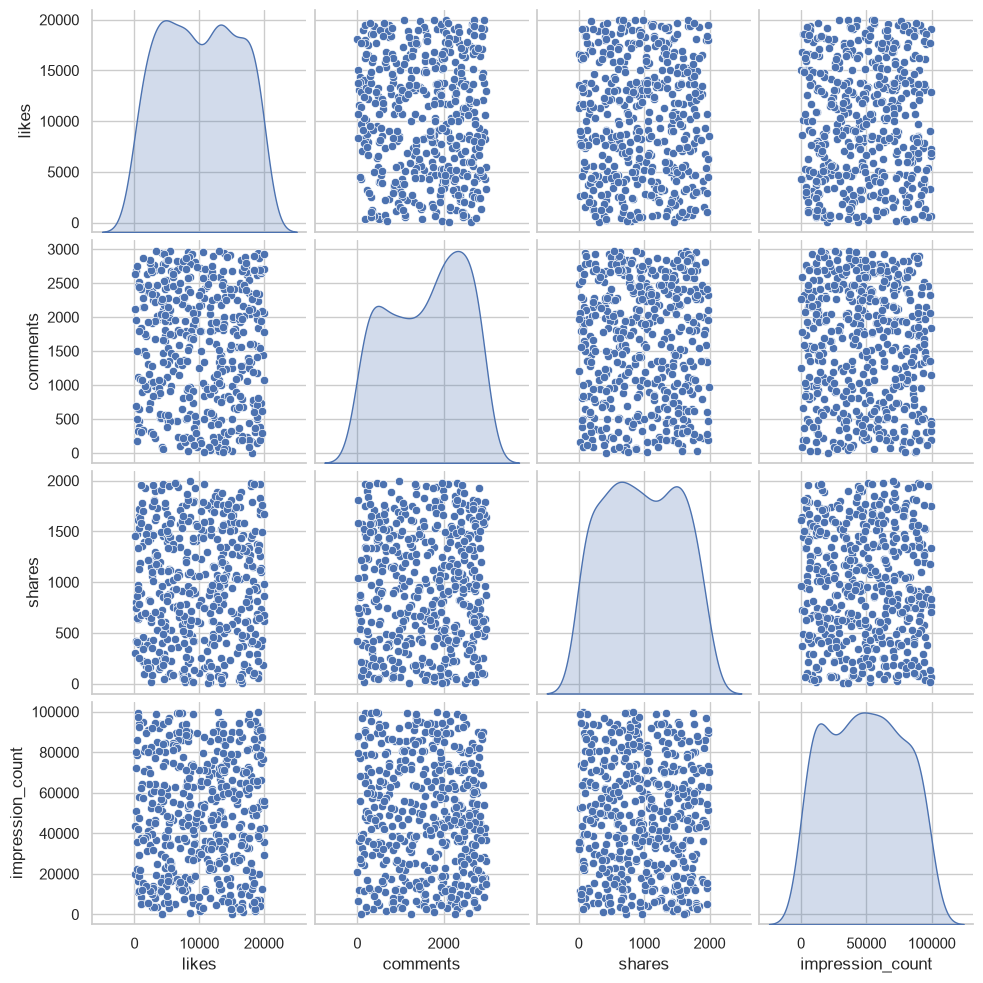

In [ ]:
sns.pairplot(df[['likes', 'comments', 'shares', 'impression_count']].sample(n=500, random_state=42), diag_kind='kde')
plt.show()


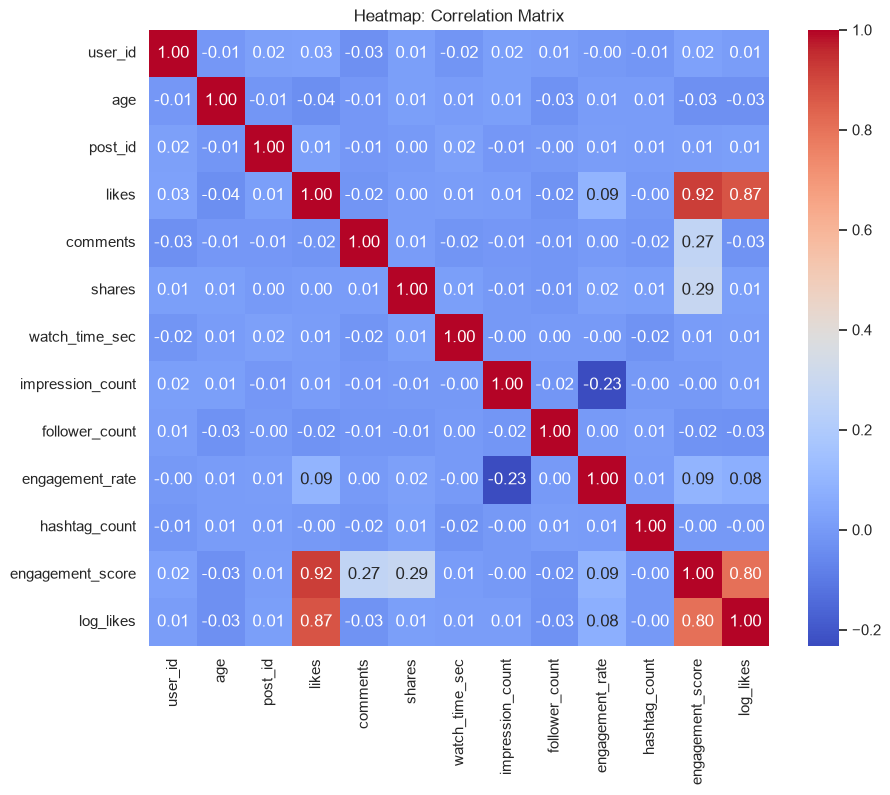

In [ ]:
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=['number'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap: Correlation Matrix')
plt.show()

C:\Users\hp\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 43.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\hp\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 58.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\hp\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 57.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\hp\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 54.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\hp\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 67.3% of the points cannot be plac

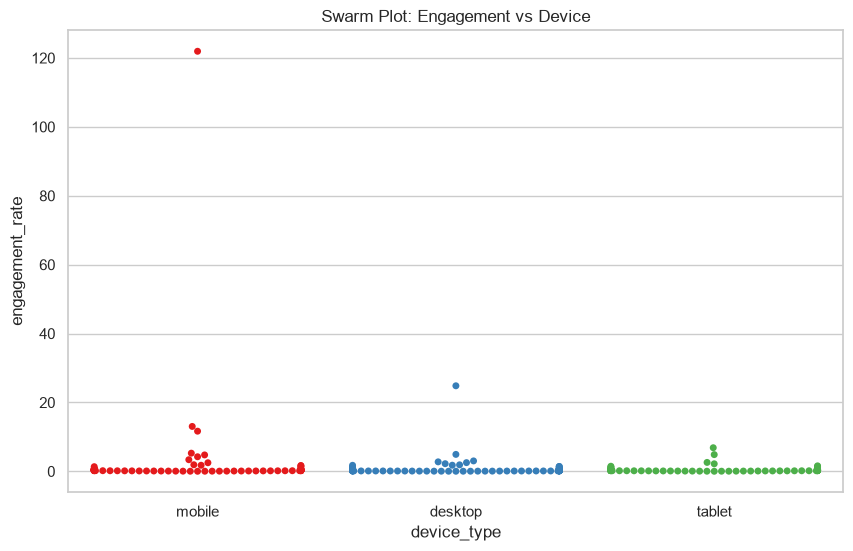

In [ ]:
plt.figure(figsize=(10, 6))
sns.swarmplot(data=df.sample(n=300, random_state=42), x='device_type', y='engagement_rate', palette='Set1', hue='device_type', legend=False)
plt.title('Swarm Plot: Engagement vs Device')
plt.show()

PLOTLY

In [ ]:

fig = px.scatter(
    df.sample(n=1000, random_state=42),
    x='impression_count',
    y='likes',
    color='post_type',
    size='comments',
    hover_data=['country', 'post_category'],
    title='Interactive Scatter: Impressions vs Likes by Post Type'
)
fig.show()

ValueError: 
    Invalid element(s) received for the 'size' property of scatter.marker
        Invalid elements include: [nan, nan, nan, nan, nan]

    The 'size' property is a number and may be specified as:
      - An int or float in the interval [0, inf]
      - A tuple, list, or one-dimensional numpy array of the above

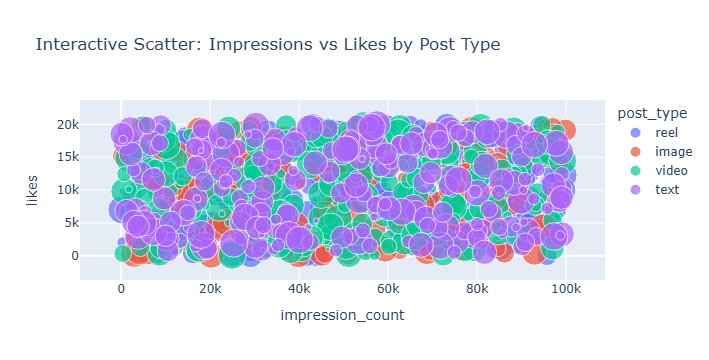

In [ ]:
plot_df = df.dropna(subset=['comments']).sample(n=1000, random_state=42)

fig = px.scatter(
    plot_df,
    x='impression_count',
    y='likes',
    color='post_type',
    size='comments',
    hover_data=['country', 'post_category'],
    title='Interactive Scatter: Impressions vs Likes by Post Type'
)
fig.show()

In [ ]:
print("--- 1. Average Engagement Rate by Post Type ---")
print(df.groupby('post_type')['engagement_rate'].mean().sort_values(ascending=False))

print("\n--- 2. Average Likes & Engagement by Content Category ---")
print(df.groupby('post_category')[['likes', 'engagement_rate']].mean().sort_values(by='engagement_rate', ascending=False))

print("\n--- 3. Average Engagement Rate by Country ---")
print(df.groupby('country')['engagement_rate'].mean().sort_values(ascending=False))


--- 1. Average Engagement Rate by Post Type ---
post_type
video    1.122365
text     1.064549
image    0.895646
reel     0.783047
Name: engagement_rate, dtype: float64

--- 2. Average Likes & Engagement by Content Category ---
                      likes  engagement_rate
post_category                               
food           10230.585237         1.358628
tech           10172.992320         1.160475
lifestyle      10184.053448         1.091019
music          10208.340872         0.888803
fitness         9910.263636         0.865628
education      10127.138889         0.844222
fashion         9835.164931         0.807109
travel         10198.951973         0.702223

--- 3. Average Engagement Rate by Country ---
country
Brazil       1.540704
Australia    1.324339
France       1.146402
UAE          1.112352
Canada       0.916659
UK           0.850966
Japan        0.769623
Germany      0.759000
India        0.655005
USA          0.576580
Name: engagement_rate, dtype: float64


In [ ]:
df['age_group'] = pd.cut(df['age'], bins=[10, 20, 30, 40, 50, 60, 70], labels=['10-20', '21-30', '31-40', '41-50', '51-60', '61-70'])
print("\n--- 4. Engagement Rate by Age Group ---")
print(df.groupby('age_group')['engagement_rate'].mean())

print("\n--- 5. Performance by Account Verification Status ---")
print(df.groupby('is_verified')[['engagement_rate', 'likes', 'follower_count']].mean())


--- 4. Engagement Rate by Age Group ---
age_group
10-20    0.802733
21-30    1.018917
31-40    0.838835
41-50    1.103215
51-60    1.106470
61-70    0.801381
Name: engagement_rate, dtype: float64

--- 5. Performance by Account Verification Status ---
             engagement_rate         likes  follower_count
is_verified                                               
False               0.954744  10138.207629   395042.837503
True                1.054250   9817.985169   381123.451346
